Sat May 30th:
Initial implementation of an MLP layer, and ridge regression, as well as weights. Found that accuracy was slightly increased with MLP and ridge regression, with regular unweighted MLP being the heighest.

In [4]:
import numpy as np
import pandas as pd
import torch
import esm   
# from Bio import SeqIO
import torch
# import gc
from sklearn.manifold import TSNE
from sklearn import metrics
import matplotlib.pyplot as plt
import pickle

from sklearn.decomposition import PCA



In [5]:
# load the dataframes
train_df_mean = pd.read_csv("../processed_data/df_Atlass_nuclear_localizations_mean_pooling.csv")
train_df_max = pd.read_csv("../processed_data/df_Atlass_nuclear_localizations_max_pooling.csv")

In [5]:
train_df_mean

,Gene,Uniprot,Protein class,Biological process,Molecular function,Subcellular main location,Nucleoplasm,Nucleoli,Nuclear Bodies,Nuclear speckles,...,emb_1270,emb_1271,emb_1272,emb_1273,emb_1274,emb_1275,emb_1276,emb_1277,emb_1278,emb_1279
0,TSPAN6,O43657,Predicted membrane proteins,NaN,NaN,"['Cell Junctions', 'Cytosol']",0,0,0,0,...,0.106142,-0.050848,-0.112138,0.019187,0.024754,0.096526,0.027279,-0.097180,-0.115552,-0.069436
1,SCYL3,Q8IZE3,"Enzymes, Predicted intracellular proteins",NaN,NaN,"['Golgi apparatus', 'Cytosol']",0,0,0,0,...,0.015452,0.040435,-0.213848,0.027658,-0.007868,-0.052791,-0.006575,-0.091785,0.081931,0.087940
2,C1orf112,Q9NSG2,Predicted intracellular proteins,NaN,NaN,['Nucleoplasm'],1,0,0,0,...,0.074599,0.056896,-0.129941,-0.010665,-0.041383,-0.003011,0.032225,-0.016146,0.028239,0.038382
3,FGR,P09769,"Disease related genes, Enzymes, Plasma protein...","Immunity, Innate immunity","Kinase, Transferase, Tyrosine-protein kinase",['Plasma membrane'],0,0,0,0,...,0.043677,-0.043478,-0.122849,0.021994,0.022644,-0.093512,0.042532,-0.135786,0.082615,0.150567
4,CFH,P08603,"Cancer-related genes, Disease related genes, H...","Complement alternate pathway, Host-virus inter...",NaN,['Vesicles'],0,0,0,0,...,0.012763,-0.094350,-0.153570,0.025493,-0.082000,0.032429,0.008535,-0.137037,-0.043967,0.178559
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12974,H2AC19,Q6FI13,Predicted intracellular proteins,NaN,DNA-binding,['Nucleoplasm'],1,0,0,0,...,-0.015420,-0.046819,-0.056484,0.098111,0.023340,-0.034530,-0.016843,-0.089375,-0.047806,0.078672
12975,ENSG00000290147,P43080,"Disease related genes, Predicted intracellular...","Sensory transduction, Vision",NaN,['Plasma membrane'],0,0,0,0,...,0.066947,-0.065718,-0.013401,0.042190,0.019360,-0.083229,-0.006085,-0.089079,-0.046900,0.189722
12976,HOMEZ,Q8IX15,"Predicted intracellular proteins, Transcriptio...","Transcription, Transcription regulation",DNA-binding,['Nucleoli'],0,1,0,0,...,-0.019209,0.015243,-0.187546,0.020428,-0.010889,-0.047901,0.037447,-0.128637,0.125876,0.055631
12977,ENSG00000290317,C9JBD0,Predicted intracellular proteins,NaN,NaN,['Nucleoplasm'],1,0,0,0,...,0.047890,0.026175,-0.022753,0.075353,-0.004008,0.107872,0.031029,0.015362,-0.088992,0.020282


In [ ]:
locations = ['Nucleoplasm', 'Nucleoli', 'Nuclear Bodies', 'Nuclear speckles',
                   'Nuclear membrane', 'Fibrillar center', 'other']

# mean
y_train_df_mean = train_df_mean[locations]
balancing_weights = y_train_df_mean.shape[0]/y_train_df_mean.sum()
x_train_df_mean = train_df_mean[[c for c in train_df_mean.columns if c.startswith('emb_')]]
print(balancing_weights)

# max
y_train_df_max = train_df_max[locations]
balancing_weights = y_train_df_max.shape[0]/y_train_df_max.sum()
x_train_df_max = train_df_max[[c for c in train_df_max.columns if c.startswith('emb_')]]

Nucleoplasm          2.767968
Nucleoli            21.035656
Nuclear Bodies      41.733119
Nuclear speckles    33.279487
Nuclear membrane    73.327684
Fibrillar center    70.156757
other                1.821614
dtype: float64


In [7]:
# generate train/dev split
from sklearn.model_selection import train_test_split

# for mean
x_train_mean, x_dev_mean, y_train_mean, y_dev_mean = train_test_split(x_train_df_mean, y_train_df_mean, test_size=0.2, random_state=42)

# for max
x_train_max, x_dev_max, y_train_max, y_dev_max = train_test_split(x_train_df_max, y_train_df_max, test_size=0.2, random_state=42)

In [8]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# load the batches and make the model for mean
x_train_mean_tensor = torch.tensor(x_train_mean.values, dtype=torch.float32)
y_train_mean_tensor = torch.tensor(y_train_mean.values, dtype=torch.float32)
train_dataset_mean = TensorDataset(x_train_mean_tensor, y_train_mean_tensor)
train_loader_mean = DataLoader(train_dataset_mean, batch_size=64, shuffle=True)

# load the batches and make the model for max
x_train_max_tensor = torch.tensor(x_train_max.values, dtype=torch.float32)
y_train_max_tensor = torch.tensor(y_train_max.values, dtype=torch.float32)
train_dataset_max = TensorDataset(x_train_max_tensor, y_train_max_tensor)
train_loader_max = DataLoader(train_dataset_max, batch_size=64, shuffle=True)

# make dev tensors
x_dev_mean_tensor = torch.tensor(x_dev_mean.values, dtype=torch.float32)
y_dev_mean_tensor = torch.tensor(y_dev_mean.values, dtype=torch.float32)
x_dev_max_tensor = torch.tensor(x_dev_max.values, dtype=torch.float32)
y_dev_max_tensor = torch.tensor(y_dev_max.values, dtype=torch.float32)

In [9]:
# make the model - multilayer perceptatron

class MLP(nn.Module):
    
    def __init__(self, input_size, num_logits):
        # call to the __init__ function of the super class
        super().__init__()

        # Bookkeeping: Sacing the initialization parameters
        self.input_size = input_size
        self.num_logits = num_logits

        # Defining the model
        self.model = nn.Sequential(
            nn.Linear(self.input_size, 64),
            nn.ReLU(),
            nn.Linear(64, self.num_logits)
        )

    def forward(self, x):
        logits = self.model(x)
        return logits
    

In [ ]:
import torch.optim as optim
from sklearn.metrics import (matthews_corrcoef, f1_score,
                             hamming_loss, jaccard_score)

# train the model

def train_model(model, loader, criterion, optimizer, x_dev_tensor, y_dev_tensor, num_epochs):
    train_loss_lst = []
    dev_loss_lst = []
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch in loader:
            x_batch, y_batch = batch
            optimizer.zero_grad()
            logits = model(x_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * x_batch.size(0)
        train_loss /= len(loader.dataset)
        train_loss_lst.append(train_loss)

        # evaluate on dev set
        model.eval()
        with torch.no_grad():
            dev_logits = model(x_dev_tensor)
            dev_loss = criterion(dev_logits, y_dev_tensor)
            dev_loss_lst.append(dev_loss.item())
        
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Dev Loss: {dev_loss.item():.4f}")
    print("Training complete.")
    return train_loss_lst, dev_loss_lst

def plot_losses(train_loss_lst, dev_loss_lst, n_epochs, experiment_title):
    plt.figure(figsize=(8, 4))
    plt.plot(range(1, n_epochs + 1), train_loss_lst, label='train')
    plt.plot(range(1, n_epochs + 1), dev_loss_lst,   label='dev')
    plt.xlabel('Epoch')
    plt.ylabel('Avg BCE Loss')
    plt.title(f"Training vs. Dev Loss for {experiment_title}")
    plt.legend()
    plt.tight_layout()
    plt.show()
    return

def run_experiment(x_train, y_train, train_loader, x_dev, y_dev, criterion, experiment_title, num_epochs):
    model = MLP(x_train.shape[1], y_train.shape[1])
    # do the weights need to match the fundamental data imbalance or the imbalance per the batch?
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loss_lst, dev_loss_lst = train_model(model, train_loader, criterion, optimizer, x_dev, y_dev, num_epochs)

    # graph the losses
    plot_losses(train_loss_lst, dev_loss_lst, num_epochs, experiment_title=experiment_title)
    return model

def compute_accuracy(model, X_dev, Y_dev, locations):
    # make predictions on dev set
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(X_dev))
        preds = (probs > 0.5).float()

    y_np   = Y_dev.numpy().astype(int)
    p_np   = preds.numpy().astype(int)

    # overall metrics (adapted from deeploc2 calculate_sl_metrics_fold)
    acc_exact   = (np.all(p_np == y_np, axis=1)).mean()
    acc_hamming = 1 - hamming_loss(y_np, p_np) 
    jaccard     = jaccard_score(y_np, p_np, average='samples') 
    micro_f1    = f1_score(y_np, p_np, average='micro', zero_division=0)
    macro_f1    = f1_score(y_np, p_np, average='macro', zero_division=0)

    print(f"Exact-match accuracy : {acc_exact:.4f}")
    print(f"Hamming accuracy     : {acc_hamming:.4f}")
    print(f"Jaccard (samples)    : {jaccard:.4f}")
    print(f"Micro F1             : {micro_f1:.4f}")
    print(f"Macro F1             : {macro_f1:.4f}")

    # per-class accuracy & MCC (adapted from deeploc2 per-class MCC loop)
    print("\nPer-class metrics:")
    print(f"{'Location':<25} {'Accuracy':>10} {'MCC':>10}")
    print("-" * 47)
    for i, loc in enumerate(locations):
        cls_acc = (p_np[:, i] == y_np[:, i]).mean()
        cls_mcc = matthews_corrcoef(y_np[:, i], p_np[:, i])
        print(f"{loc:<25} {cls_acc:>10.4f} {cls_mcc:>10.4f}")


Epoch 1/100, Train Loss: 0.3110, Dev Loss: 0.2471
Epoch 11/100, Train Loss: 0.2249, Dev Loss: 0.2267
Epoch 21/100, Train Loss: 0.2166, Dev Loss: 0.2256
Epoch 31/100, Train Loss: 0.2103, Dev Loss: 0.2272
Epoch 41/100, Train Loss: 0.2046, Dev Loss: 0.2292
Epoch 51/100, Train Loss: 0.1987, Dev Loss: 0.2329
Epoch 61/100, Train Loss: 0.1944, Dev Loss: 0.2395
Epoch 71/100, Train Loss: 0.1882, Dev Loss: 0.2396
Epoch 81/100, Train Loss: 0.1833, Dev Loss: 0.2446
Epoch 91/100, Train Loss: 0.1780, Dev Loss: 0.2475
Epoch 100/100, Train Loss: 0.1736, Dev Loss: 0.2525
Training complete.


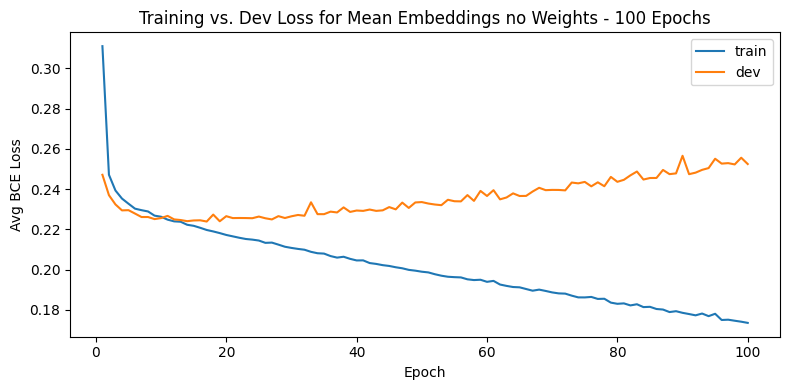

Exact-match accuracy : 0.6125
Hamming accuracy     : 0.9074
Jaccard (samples)    : 0.6278
Micro F1             : 0.6653
Macro F1             : 0.2799

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Nucleoplasm                   0.7350     0.4012
Nucleoli                      0.9680     0.3719
Nuclear Bodies                0.9742     0.0830
Nuclear speckles              0.9753     0.2118
Nuclear membrane              0.9838     0.1623
Fibrillar center              0.9834     0.0000
other                         0.7323     0.4527


In [11]:
# experiment 1: control with no reweighting on mean - 100 epochs
criterion_1 = nn.BCEWithLogitsLoss()
reg_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_1, experiment_title="Mean Embeddings no Weights - 100 Epochs", num_epochs=100)
compute_accuracy(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# experiment 2: no reweighting on max - 100 epochs
criterion_2 = nn.BCEWithLogitsLoss()
reg_model_max = run_experiment(x_train_max_tensor, y_train_max_tensor, train_loader_max, x_dev_max_tensor, y_dev_max_tensor, criterion_2, experiment_title="Max Embeddings no Weights - 100 Epochs", num_epochs=100)
compute_accuracy(reg_model_max, x_dev_max_tensor, y_dev_max_tensor, locations)

Epoch 1/100, Train Loss: 5.4742, Dev Loss: 3.8955
Epoch 11/100, Train Loss: 3.4167, Dev Loss: 3.6805
Epoch 21/100, Train Loss: 3.2237, Dev Loss: 3.7480
Epoch 31/100, Train Loss: 3.0262, Dev Loss: 3.8426
Epoch 41/100, Train Loss: 2.8592, Dev Loss: 3.9827
Epoch 51/100, Train Loss: 2.7064, Dev Loss: 4.1063
Epoch 61/100, Train Loss: 2.5518, Dev Loss: 4.2976
Epoch 71/100, Train Loss: 2.4051, Dev Loss: 4.5517
Epoch 81/100, Train Loss: 2.2415, Dev Loss: 4.6349
Epoch 91/100, Train Loss: 2.0815, Dev Loss: 4.8292
Epoch 100/100, Train Loss: 1.9597, Dev Loss: 5.2446
Training complete.


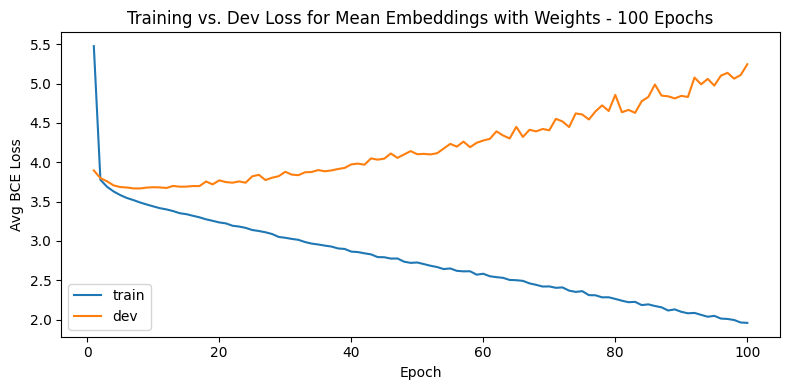

Exact-match accuracy : 0.6144
Hamming accuracy     : 0.9084
Jaccard (samples)    : 0.6310
Micro F1             : 0.6697
Macro F1             : 0.2903

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Nucleoplasm                   0.7481     0.4346
Nucleoli                      0.9676     0.3864
Nuclear Bodies                0.9730     0.0483
Nuclear speckles              0.9723     0.1635
Nuclear membrane              0.9831     0.1059
Fibrillar center              0.9831     0.0844
other                         0.7315     0.4528


In [12]:
# experiment 3: reweighting on mean - 100 epochs
criterion_3 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_3,  experiment_title="Mean Embeddings with Weights - 100 Epochs", num_epochs=100)
compute_accuracy(reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# experiment 4: reweighting on max - 100 epochs
criterion_4 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
reweighting_model_max = run_experiment(x_train_max_tensor, y_train_max_tensor, train_loader_max, x_dev_max_tensor, y_dev_max_tensor, criterion_4, experiment_title="Max Embeddings with Weights - 100 Epochs", num_epochs=100)
compute_accuracy(reweighting_model_max, x_dev_max_tensor, y_dev_max_tensor, locations)

In [ ]:
# experiment 5: no reweighting on mean - 200 epochs
criterion_5 = nn.BCEWithLogitsLoss()
reg_model_mean_200 = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_5, experiment_title="Mean Embeddings no Weights - 200 Epochs", num_epochs=200)
compute_accuracy(reg_model_mean_200, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# experiment 6: baseline nonsense data

# make nonsense data by shuffling the labels
y_dev_mean_tensor_shuffled = y_dev_mean_tensor[torch.randperm(y_dev_mean_tensor.size(0))]

# compute accuracy of the original model on the shuffled labels as a sanity check - should be very low
compute_accuracy(reg_model_mean, x_dev_mean_tensor, y_dev_mean_tensor_shuffled, locations)

In [ ]:
# experiment 7: investigate focal loss - mean - 100 epochs
import torchvision

def focal_loss(logits, y_train):
    return torchvision.ops.sigmoid_focal_loss(logits, y_train, reduction='mean')
criterion_9 = focal_loss
reweighting_model_mean = run_experiment(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_9,  experiment_title="Mean Embeddings with focal loss", num_epochs=100)
compute_accuracy(reweighting_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [22]:
# prepare for experiment with ridge regression in the loss function - mean - 100 epochs

# this function is slightly different than the normal train model function because we 
# need to compute the dev loss with the normal criterion, not the regression criterion
# in order to track the actual performance of the model, not just the regression loss
def train_regressed_model(model, loader, criterion_reg, criterion, optimizer, x_dev_tensor, y_dev_tensor, num_epochs, lambda_reg):
    train_loss_lst = []
    dev_loss_lst = []
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for batch in loader:
            x_batch, y_batch = batch
            optimizer.zero_grad()
            logits = model(x_batch)
            loss_grad = criterion(logits, y_batch) + criterion_reg(model.model[0].weight, model.model[2].weight, lambda_reg)
            loss_grad.backward()
            optimizer.step()
            
            # get the actual loss without regression
            loss = criterion(logits, y_batch)
            train_loss += loss.item() * x_batch.size(0)
        train_loss /= len(loader.dataset)
        train_loss_lst.append(train_loss)

        # evaluate on dev set
        model.eval()
        with torch.no_grad():
            dev_logits = model(x_dev_tensor)
            dev_loss = criterion(dev_logits, y_dev_tensor)
            dev_loss_lst.append(dev_loss.item())
        
        if epoch % 10 == 0 or epoch == num_epochs - 1:
            print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Dev Loss: {dev_loss.item():.4f}")
    print("Training complete.")
    return train_loss_lst, dev_loss_lst

# need a new experiment function too to pass the parameters
def run_experiment_reg(x_train, y_train, train_loader, x_dev, y_dev, criterion_reg, criterion_wo_reg, lambda_reg, experiment_title, num_epochs):
    model = MLP(x_train.shape[1], y_train.shape[1])
    # do the weights need to match the fundamental data imbalance or the imbalance per the batch?
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    train_loss_lst, dev_loss_lst = train_regressed_model(model, train_loader, criterion_reg, criterion_wo_reg, optimizer, x_dev, y_dev, num_epochs, lambda_reg)

    # graph the losses
    plot_losses(train_loss_lst, dev_loss_lst, num_epochs, experiment_title=experiment_title)
    return model

Epoch 1/100, Train Loss: 0.2987, Dev Loss: 0.2435
Epoch 11/100, Train Loss: 0.2295, Dev Loss: 0.2301
Epoch 21/100, Train Loss: 0.2261, Dev Loss: 0.2272
Epoch 31/100, Train Loss: 0.2241, Dev Loss: 0.2250
Epoch 41/100, Train Loss: 0.2227, Dev Loss: 0.2248
Epoch 51/100, Train Loss: 0.2215, Dev Loss: 0.2329
Epoch 61/100, Train Loss: 0.2195, Dev Loss: 0.2261
Epoch 71/100, Train Loss: 0.2182, Dev Loss: 0.2254
Epoch 81/100, Train Loss: 0.2163, Dev Loss: 0.2259
Epoch 91/100, Train Loss: 0.2155, Dev Loss: 0.2285
Epoch 100/100, Train Loss: 0.2145, Dev Loss: 0.2271
Training complete.


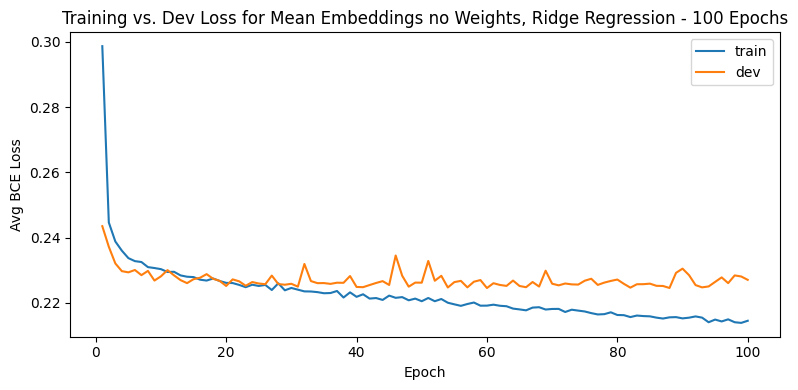

Exact-match accuracy : 0.6237
Hamming accuracy     : 0.9118
Jaccard (samples)    : 0.6350
Micro F1             : 0.6769
Macro F1             : 0.2254

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Nucleoplasm                   0.7581     0.4532
Nucleoli                      0.9657     0.2658
Nuclear Bodies                0.9742     0.0000
Nuclear speckles              0.9746     0.0000
Nuclear membrane              0.9846     0.0000
Fibrillar center              0.9834     0.0000
other                         0.7419     0.4728


In [25]:
# experiment 8 ridge resgression on mean - 100 epochs

def ridge_regression(w1, w2, lambda_reg):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg = ridge_regression
criterion_wo_reg = nn.BCEWithLogitsLoss()
title = "Mean Embeddings no Weights, Ridge Regression - 100 Epochs"
lambda_reg = 0.0001
regression_model_mean = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg, criterion_wo_reg, lambda_reg, experiment_title=title, num_epochs=100)
compute_accuracy(regression_model_mean, x_dev_mean_tensor, y_dev_mean_tensor, locations)

Epoch 1/100, Train Loss: 5.3497, Dev Loss: 3.8458
Epoch 11/100, Train Loss: 3.4896, Dev Loss: 3.6698
Epoch 21/100, Train Loss: 3.3891, Dev Loss: 3.6587
Epoch 31/100, Train Loss: 3.3048, Dev Loss: 3.6734
Epoch 41/100, Train Loss: 3.2249, Dev Loss: 3.7899
Epoch 51/100, Train Loss: 3.1240, Dev Loss: 3.8422
Epoch 61/100, Train Loss: 3.0641, Dev Loss: 3.7803
Epoch 71/100, Train Loss: 2.9891, Dev Loss: 3.8576
Epoch 81/100, Train Loss: 2.9125, Dev Loss: 3.8681
Epoch 91/100, Train Loss: 2.8530, Dev Loss: 3.8932
Epoch 100/100, Train Loss: 2.7716, Dev Loss: 3.9887
Training complete.


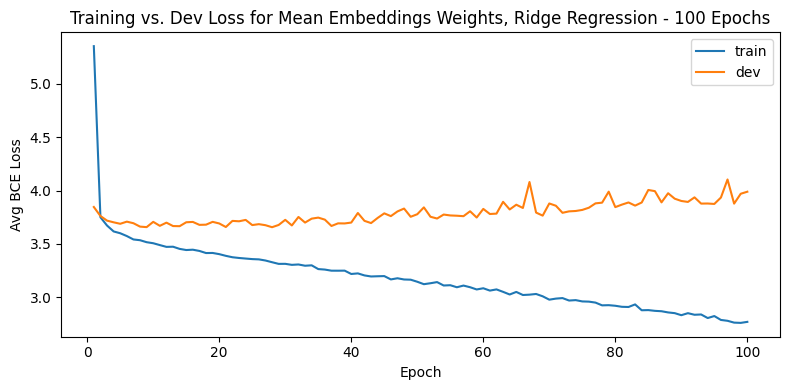

Exact-match accuracy : 0.6283
Hamming accuracy     : 0.9115
Jaccard (samples)    : 0.6390
Micro F1             : 0.6774
Macro F1             : 0.2316

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Nucleoplasm                   0.7531     0.4370
Nucleoli                      0.9669     0.3100
Nuclear Bodies                0.9742     0.0000
Nuclear speckles              0.9746     0.0837
Nuclear membrane              0.9846     0.0000
Fibrillar center              0.9834     0.0000
other                         0.7438     0.4753


In [24]:
# experiment 9 - ridge resgression on mean weighted - 100 epochs

def ridge_regression(w1, w2, lambda_reg):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_9 = ridge_regression
criterion_wo_reg_9 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression - 100 Epochs"
lambda_reg = 0.001
regression_model_mean_9 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_9, criterion_wo_reg_9, lambda_reg, experiment_title=title, num_epochs=100)
compute_accuracy(regression_model_mean_9, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# experiment 10 - ridge resgression on mean weighted - 200 epochs

def ridge_regression(w1, w2, lambda_reg):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_10 = ridge_regression
criterion_wo_reg_10 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression - 200 Epochs"
regression_model_mean_10 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_10, criterion_wo_reg_10, experiment_title=title, num_epochs=200)
compute_accuracy(regression_model_mean_10, x_dev_mean_tensor, y_dev_mean_tensor, locations)

In [ ]:
# experiment 11 - ridge resgression on mean weighted - 200 epochs, lambda = 0.01

def ridge_regression(w1, w2, lambda_reg=0.01):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_11 = ridge_regression
criterion_wo_reg_11 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression, lambda = 0.01 - 200 Epochs"
regression_model_mean_11 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_11, criterion_wo_reg_11, experiment_title=title, num_epochs=200)
compute_accuracy(regression_model_mean_11, x_dev_mean_tensor, y_dev_mean_tensor, locations)

Epoch 1/100, Train Loss: 5.7276, Dev Loss: 3.8561
Epoch 11/100, Train Loss: 3.4394, Dev Loss: 3.6847
Epoch 21/100, Train Loss: 3.2355, Dev Loss: 3.7426
Epoch 31/100, Train Loss: 3.0329, Dev Loss: 3.8404
Epoch 41/100, Train Loss: 2.8490, Dev Loss: 3.9735
Epoch 51/100, Train Loss: 2.7075, Dev Loss: 4.0908
Epoch 61/100, Train Loss: 2.5144, Dev Loss: 4.2042
Epoch 71/100, Train Loss: 2.3542, Dev Loss: 4.4433
Epoch 81/100, Train Loss: 2.1940, Dev Loss: 4.5127
Epoch 91/100, Train Loss: 2.0404, Dev Loss: 4.9943
Epoch 100/100, Train Loss: 1.9248, Dev Loss: 5.0521
Training complete.


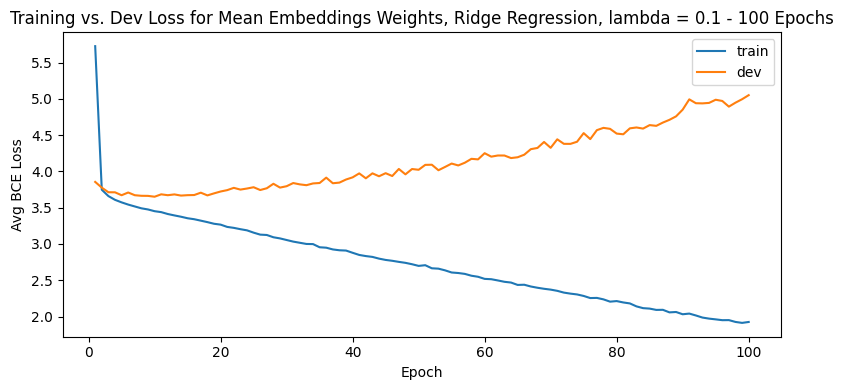

Exact-match accuracy : 0.6433
Hamming accuracy     : 0.9115
Jaccard (samples)    : 0.6572
Micro F1             : 0.6850
Macro F1             : 0.2878

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Nucleoplasm                   0.7515     0.4350
Nucleoli                      0.9684     0.3756
Nuclear Bodies                0.9742     0.0830
Nuclear speckles              0.9757     0.2276
Nuclear membrane              0.9819     0.1240
Fibrillar center              0.9834     0.1052
other                         0.7454     0.4792


In [20]:
# experiment 12 - ridge resgression on mean weighted - 100 epochs, lambda = 0.1

def ridge_regression(w1, w2, lambda_reg=-1000):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_12 = ridge_regression
criterion_wo_reg_12 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression, lambda = 0.1 - 100 Epochs"
regression_model_mean_12 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_12, criterion_wo_reg_12, experiment_title=title, num_epochs=100)
compute_accuracy(regression_model_mean_12, x_dev_mean_tensor, y_dev_mean_tensor, locations)

Epoch 1/200, Train Loss: 4.4426, Dev Loss: 2.9074
Epoch 11/200, Train Loss: 1.7766, Dev Loss: 1.7641
Epoch 21/200, Train Loss: 1.5177, Dev Loss: 1.6641
Epoch 31/200, Train Loss: 1.3552, Dev Loss: 1.6161
Epoch 41/200, Train Loss: 1.2293, Dev Loss: 1.5869
Epoch 51/200, Train Loss: 1.1356, Dev Loss: 1.6180
Epoch 61/200, Train Loss: 1.0520, Dev Loss: 1.5753
Epoch 71/200, Train Loss: 0.9826, Dev Loss: 1.5948
Epoch 81/200, Train Loss: 0.9381, Dev Loss: 1.6530
Epoch 91/200, Train Loss: 0.8853, Dev Loss: 1.6522
Epoch 101/200, Train Loss: 0.8517, Dev Loss: 1.6623
Epoch 111/200, Train Loss: 0.8087, Dev Loss: 1.6718
Epoch 121/200, Train Loss: 0.7875, Dev Loss: 1.6727
Epoch 131/200, Train Loss: 0.7460, Dev Loss: 1.7177
Epoch 141/200, Train Loss: 0.7196, Dev Loss: 1.7261
Epoch 151/200, Train Loss: 0.6978, Dev Loss: 1.7206
Epoch 161/200, Train Loss: 0.6713, Dev Loss: 1.7695
Epoch 171/200, Train Loss: 0.6564, Dev Loss: 1.7469
Epoch 181/200, Train Loss: 0.6428, Dev Loss: 1.7678
Epoch 191/200, Train Lo

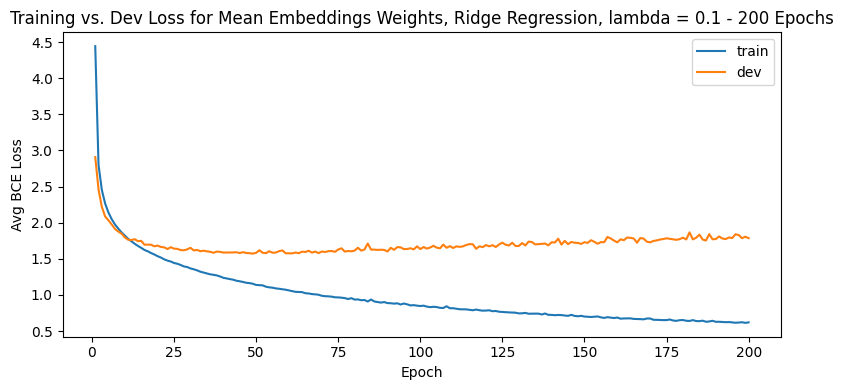

Exact-match accuracy : 0.5287
Hamming accuracy     : 0.9323
Jaccard (samples)    : 0.6948
Micro F1             : 0.7521
Macro F1             : 0.6883

Per-class metrics:
Location                    Accuracy        MCC
-----------------------------------------------
Membrane                      0.8851     0.7187
Cytoplasm                     0.8123     0.5898
Nucleus                       0.8399     0.6485
Extracellular                 0.9769     0.8899
Cell membrane                 0.9281     0.6921
Mitochondrion                 0.9620     0.7338
Plastid                       0.9923     0.8923
Endoplasmic reticulum         0.9444     0.5563
Lysosome/Vacuole              0.9557     0.4712
Golgi apparatus               0.9643     0.5590
Peroxisome                    0.9941     0.3820


In [34]:
# experiment 13 - ridge resgression on mean weighted - 200 epochs, lambda = 0.1

def ridge_regression(w1, w2, lambda_reg=0.5):
    y = lambda_reg*(torch.linalg.matrix_norm(w1)**2 + torch.linalg.matrix_norm(w2)**2)
    return y

criterion_reg_13 = ridge_regression
criterion_wo_reg_13 = nn.BCEWithLogitsLoss(weight=torch.tensor(balancing_weights.values, dtype=torch.float32))
title = "Mean Embeddings Weights, Ridge Regression, lambda = 0.1 - 200 Epochs"
regression_model_mean_13 = run_experiment_reg(x_train_mean_tensor, y_train_mean_tensor, train_loader_mean, x_dev_mean_tensor, y_dev_mean_tensor, criterion_reg_13, criterion_wo_reg_13, experiment_title=title, num_epochs=200)
compute_accuracy(regression_model_mean_13, x_dev_mean_tensor, y_dev_mean_tensor, locations)